In [ ]:
pip install simfin

In [2]:
import pandas as pd
import numpy as np
# Jupyter widget progress bar
from tqdm import tqdm_notebook as tqdm
# Pickle to import and export the formatted datasets
import _pickle as pickle
# import the data
import simfin as sf

In [9]:
sf.set_api_key('free')
sf.set_data_dir('~/simfin_data/')


In [ ]:

df = sf.load_income(variant='quarterly', market='us')
df3 = sf.load_balance(variant='quarterly', market='us')
df4 = sf.load_cashflow(variant='quarterly', market='us')

In [29]:
df4.head()
df4.shape

(71977, 26)

In [19]:
df3.shape
df.shape

(71977, 26)

In [6]:
data = pd.merge(df, df3,  how='left', on=['SimFinId','Fiscal Year', 'Fiscal Period','Currency', 'Publish Date','Shares (Basic)','Restated Date','Shares (Diluted)'])
data = pd.merge(data, df4,  how='left', on=['SimFinId','Fiscal Year', 'Fiscal Period','Currency', 'Publish Date','Shares (Basic)','Restated Date','Shares (Diluted)'])
data.shape

(71977, 64)

In [102]:
data.columns

Index(['SimFinId', 'Currency', 'Fiscal Year', 'Fiscal Period', 'Publish Date',
       'Restated Date', 'Shares (Basic)', 'Shares (Diluted)', 'Revenue',
       'Cost of Revenue', 'Gross Profit', 'Operating Expenses',
       'Selling, General & Administrative', 'Research & Development',
       'Depreciation & Amortization_x', 'Operating Income (Loss)',
       'Non-Operating Income (Loss)', 'Interest Expense, Net',
       'Pretax Income (Loss), Adj.', 'Abnormal Gains (Losses)',
       'Pretax Income (Loss)', 'Income Tax (Expense) Benefit, Net',
       'Income (Loss) from Continuing Operations',
       'Net Extraordinary Gains (Losses)', 'Net Income', 'Net Income (Common)',
       'Cash, Cash Equivalents & Short Term Investments',
       'Accounts & Notes Receivable', 'Inventories', 'Total Current Assets',
       'Property, Plant & Equipment, Net',
       'Long Term Investments & Receivables', 'Other Long Term Assets',
       'Total Noncurrent Assets', 'Total Assets', 'Payables & Accruals'

In [23]:
df2 = sf.load_shareprices(variant='daily', market='us', index=['Ticker'])

Dataset "us-shareprices-daily" on disk (2 days old).
- Loading from disk ... Done!


In [14]:
df2.head()

Ticker    Open     Low    High   Close  Adj. Close  \
SimFinId Date                                                            
18       2014-03-27   GOOG  568.00  552.92  568.00  558.46      558.46   
         2014-03-28   GOOG  561.20  558.67  566.43  559.99      559.99   
         2014-03-31   GOOG  566.89  556.93  567.00  556.97      556.97   
         2014-04-01   GOOG  558.71  558.71  568.45  567.16      567.16   
         2014-04-02   GOOG  565.11  562.19  604.83  567.00      567.00   

                     Dividend  Volume  Shares Outstanding  
SimFinId Date                                              
18       2014-03-27       NaN   13100         336050831.0  
         2014-03-28       NaN   41100         336050831.0  
         2014-03-31       NaN   10800         674462000.0  
         2014-04-01       NaN    7900         674462000.0  
         2014-04-02       NaN  146700         674462000.0

In [9]:
minidata = data[0:500]
minidata.head()

,SimFinId,Currency,Fiscal Year,Fiscal Period,Publish Date,Restated Date,Shares (Basic),Shares (Diluted),Revenue,Cost of Revenue,...,Net Cash from Operating Activities,Change in Fixed Assets & Intangibles,Net Change in Long Term Investment,Net Cash from Acquisitions & Divestitures,Net Cash from Investing Activities,Dividends Paid,Cash from (Repayment of) Debt,Cash from (Repurchase of) Equity,Net Cash from Financing Activities,Net Change in Cash
0,45846,USD,2010,Q3,2010-10-06,2011-09-07,347000000.0,352000000.0,1.384000e+09,-659000000.0,...,90000000.0,-27000000.0,30000000.0,-1.102000e+09,-1.112000e+09,NaN,7.470000e+08,-54000000.0,6.880000e+08,-329000000.0
1,45846,USD,2010,Q4,2010-12-20,2012-12-20,344000000.0,356000000.0,1.576000e+09,-742000000.0,...,373000000.0,-34000000.0,0.0,-1.400000e+07,-1.400000e+07,0.0,-2.900000e+07,-17000000.0,-4.600000e+07,332000000.0
2,45846,USD,2011,Q1,2011-03-09,2012-03-05,347000000.0,355000000.0,1.519000e+09,-703000000.0,...,120000000.0,-38000000.0,5000000.0,0.000000e+00,1.500000e+09,NaN,-1.500000e+09,-134000000.0,-1.634000e+09,-11000000.0
3,45846,USD,2011,Q2,2011-06-07,2012-06-04,347000000.0,355000000.0,1.677000e+09,-777000000.0,...,378000000.0,-51000000.0,9000000.0,-9.600000e+07,-1.260000e+08,0.0,0.000000e+00,68000000.0,6.800000e+07,337000000.0
4,45846,USD,2011,Q3,2011-09-07,2012-09-05,348000000.0,357000000.0,1.691000e+09,-799000000.0,...,252000000.0,-32000000.0,0.0,0.000000e+00,-3.200000e+07,0.0,0.000000e+00,-97000000.0,-9.700000e+07,126000000.0


In [18]:
def grab_offset_close(row, days_offset, recursions):
    if (recursions > 3):
        return None
    try: 
        return df2.loc[row['SimFinId'], (row['Publish Date'] + pd.Timedelta(days=days_offset))]['Close']
    except KeyError:
        return grab_offset_close(row, days_offset -2, recursions+1)

In [20]:
data['YesterdaySharePrice'] = list(data.apply(grab_offset_close, axis=1,args=(-1,0)))

In [11]:
minidata['YesterdaySharePrice'] = list(minidata.apply(grab_offset_close, axis=1,args=(-1,0)))

/Users/andrewriordan/anaconda2/lib/python3.7/site-packages/ipykernel_launcher.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  """Entry point for launching an IPython kernel.


In [21]:
data['NinetyDaySharePrice'] = list(data.apply(grab_offset_close, axis=1,args=(90,0)))

In [22]:
data['Increase'] = data['NinetyDaySharePrice'] / data['YesterdaySharePrice']

In [29]:
data.to_csv( "./PredictionData.csv")

In [226]:
data.head()

,SimFinId,Currency,Fiscal Year,Fiscal Period,Publish Date,Restated Date,Shares (Basic),Shares (Diluted),Revenue,Cost of Revenue,...,Net Cash from Acquisitions & Divestitures,Net Cash from Investing Activities,Dividends Paid,Cash from (Repayment of) Debt,Cash from (Repurchase of) Equity,Net Cash from Financing Activities,Net Change in Cash,YesterdaySharePrice,NinetyDaySharePrice,Increase
0,45846,USD,2010,Q3,2010-10-06,2011-09-07,347000000.0,352000000.0,1.384000e+09,-659000000.0,...,-1.102000e+09,-1.112000e+09,NaN,7.470000e+08,-54000000.0,6.880000e+08,-329000000.0,33.04,41.49,1.255751
1,45846,USD,2010,Q4,2010-12-20,2012-12-20,344000000.0,356000000.0,1.576000e+09,-742000000.0,...,-1.400000e+07,-1.400000e+07,0.0,-2.900000e+07,-17000000.0,-4.600000e+07,332000000.0,NaN,NaN,NaN
2,45846,USD,2011,Q1,2011-03-09,2012-03-05,347000000.0,355000000.0,1.519000e+09,-703000000.0,...,0.000000e+00,1.500000e+09,NaN,-1.500000e+09,-134000000.0,-1.634000e+09,-11000000.0,45.97,47.70,1.037633
3,45846,USD,2011,Q2,2011-06-07,2012-06-04,347000000.0,355000000.0,1.677000e+09,-777000000.0,...,-9.600000e+07,-1.260000e+08,0.0,0.000000e+00,68000000.0,6.800000e+07,337000000.0,47.06,NaN,NaN
4,45846,USD,2011,Q3,2011-09-07,2012-09-05,348000000.0,357000000.0,1.691000e+09,-799000000.0,...,0.000000e+00,-3.200000e+07,0.0,0.000000e+00,-97000000.0,-9.700000e+07,126000000.0,33.92,36.98,1.090212


In [229]:
data2 = data[data.Increase.notnull()]

In [3]:
data = pd.read_csv('PredictionData.csv')

In [4]:
data.head()

,Unnamed: 0,SimFinId,Currency,Fiscal Year,Fiscal Period,Publish Date,Restated Date,Shares (Basic),Shares (Diluted),Revenue,...,Net Cash from Acquisitions & Divestitures,Net Cash from Investing Activities,Dividends Paid,Cash from (Repayment of) Debt,Cash from (Repurchase of) Equity,Net Cash from Financing Activities,Net Change in Cash,YesterdaySharePrice,NinetyDaySharePrice,Increase
0,0,45846,USD,2010,Q3,2010-10-06,2011-09-07,347000000.0,352000000.0,1.384000e+09,...,-1.102000e+09,-1.112000e+09,NaN,7.470000e+08,-54000000.0,6.880000e+08,-329000000.0,33.04,41.49,1.255751
1,1,45846,USD,2010,Q4,2010-12-20,2012-12-20,344000000.0,356000000.0,1.576000e+09,...,-1.400000e+07,-1.400000e+07,0.0,-2.900000e+07,-17000000.0,-4.600000e+07,332000000.0,40.54,42.94,1.059201
2,2,45846,USD,2011,Q1,2011-03-09,2012-03-05,347000000.0,355000000.0,1.519000e+09,...,0.000000e+00,1.500000e+09,NaN,-1.500000e+09,-134000000.0,-1.634000e+09,-11000000.0,45.97,47.70,1.037633
3,3,45846,USD,2011,Q2,2011-06-07,2012-06-04,347000000.0,355000000.0,1.677000e+09,...,-9.600000e+07,-1.260000e+08,0.0,0.000000e+00,68000000.0,6.800000e+07,337000000.0,47.06,35.84,0.761581
4,4,45846,USD,2011,Q3,2011-09-07,2012-09-05,348000000.0,357000000.0,1.691000e+09,...,0.000000e+00,-3.200000e+07,0.0,0.000000e+00,-97000000.0,-9.700000e+07,126000000.0,33.92,36.98,1.090212


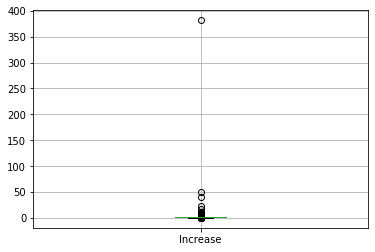

In [6]:
data.boxplot(column=['Increase'])

In [13]:
data.sort_values(by=['Increase'], ascending=False, na_position='last')

,Unnamed: 0,SimFinId,Currency,Fiscal Year,Fiscal Period,Publish Date,Restated Date,Shares (Basic),Shares (Diluted),Revenue,...,Net Cash from Acquisitions & Divestitures,Net Cash from Investing Activities,Dividends Paid,Cash from (Repayment of) Debt,Cash from (Repurchase of) Equity,Net Cash from Financing Activities,Net Change in Cash,YesterdaySharePrice,NinetyDaySharePrice,Increase
21501,21501,352819,USD,2016,Q3,2016-11-01,2016-11-01,NaN,NaN,2.026000e+09,...,0.0,-171000000.0,NaN,879000000.0,NaN,1.225000e+09,1.238000e+09,0.03,11.45,381.666667
64918,64918,692917,USD,2011,Q2,2011-08-15,2012-08-09,57455491.0,57455491.0,5.083030e+05,...,NaN,-275707.0,NaN,530211.0,607000.0,1.137211e+06,5.972200e+04,0.01,0.51,51.000000
60191,60191,511627,USD,2014,Q3,2014-11-13,2015-11-16,3945925.0,3947376.0,6.086465e+06,...,0.0,0.0,NaN,-93101.0,0.0,-9.310100e+04,5.112320e+05,0.14,5.70,40.714286
51515,51515,778232,USD,2016,Q4,2017-04-13,2018-04-13,28853.0,28853.0,6.180000e+05,...,NaN,NaN,NaN,300000.0,NaN,3.000000e+05,-1.700000e+04,8.18,184.20,22.518337
37597,37597,155590,USD,2012,Q2,2012-08-13,2013-08-21,5200623.0,5200623.0,4.469733e+06,...,NaN,-79861.0,NaN,-264433.0,NaN,-2.644330e+05,-7.148100e+04,0.03,0.51,17.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
71894,71894,994625,USD,2017,Q4,2018-03-15,2020-03-31,25535000.0,25535000.0,5.299600e+07,...,0.0,-2218000.0,NaN,-1916000.0,1822000.0,-7.040000e+05,-9.255000e+06,NaN,29.74,NaN
71904,71904,994625,USD,2020,Q2,2020-09-04,2021-09-03,116838000.0,116838000.0,7.498900e+07,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,11.22,NaN,NaN
71941,71941,901866,USD,2020,Q2,2020-08-03,2021-07-28,32137000.0,32501000.0,1.039400e+08,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.94,NaN,NaN
71962,71962,901704,USD,2020,Q2,2020-08-10,2021-08-09,26100264.0,26100264.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.22,NaN,NaN


In [31]:
data[data['SimFinId'] == 352819]

,Unnamed: 0,SimFinId,Currency,Fiscal Year,Fiscal Period,Publish Date,Restated Date,Shares (Basic),Shares (Diluted),Revenue,...,Net Cash from Acquisitions & Divestitures,Net Cash from Investing Activities,Dividends Paid,Cash from (Repayment of) Debt,Cash from (Repurchase of) Equity,Net Cash from Financing Activities,Net Change in Cash,YesterdaySharePrice,NinetyDaySharePrice,Increase
21499,21499,352819,USD,2016,Q1,2016-05-09,2016-05-09,NaN,NaN,1.113000e+09,...,NaN,-9.500000e+07,NaN,-1.200000e+07,NaN,-1.680000e+08,-5.330000e+08,0.03,0.03,1.000000
21500,21500,352819,USD,2016,Q2,2016-08-02,2016-08-02,NaN,NaN,1.115000e+09,...,-1.343000e+09,-1.425000e+09,NaN,1.114000e+09,NaN,1.242000e+09,-4.250000e+08,11.43,0.03,0.002625
21501,21501,352819,USD,2016,Q3,2016-11-01,2016-11-01,NaN,NaN,2.026000e+09,...,0.000000e+00,-1.710000e+08,NaN,8.790000e+08,NaN,1.225000e+09,1.238000e+09,0.03,11.45,381.666667


In [32]:
df2[df2['SimFinId'] == 352819].

,SimFinId,Date,Open,Low,High,Close,Adj. Close,Dividend,Volume,Shares Outstanding
Ticker,,,,,,,,,,
EFH,352819,2013-04-12,0.58,0.53,0.58,0.54,0.54,NaN,13502,1.681909e+09
EFH,352819,2013-04-11,0.57,0.53,0.61,0.55,0.55,NaN,118167,1.681909e+09
EFH,352819,2013-04-10,0.50,0.50,0.57,0.57,0.57,NaN,222050,1.681909e+09
EFH,352819,2013-04-09,0.46,0.45,0.49,0.49,0.49,NaN,34974,1.681909e+09
EFH,352819,2013-04-08,0.43,0.43,0.46,0.45,0.45,NaN,10235,1.681909e+09
...,...,...,...,...,...,...,...,...,...,...
EFH,352819,2011-02-23,9.70,9.30,10.00,9.90,9.90,NaN,47204,1.671812e+09
EFH,352819,2011-02-24,7.65,7.65,7.65,7.65,7.65,NaN,194,1.671812e+09
EFH,352819,2011-02-25,7.84,7.80,7.91,7.88,7.88,NaN,33040,1.671812e+09


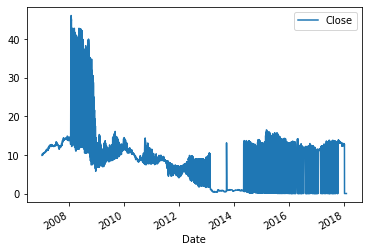

In [34]:
df2[df2['SimFinId'] == 352819].plot.line(x='Date', y='Close')

In [37]:
import pandas_bokeh
pandas_bokeh.output_notebook()

Loading BokehJS ...

In [36]:
pip install pandas_bokeh

     |████████████████████████████████| 18.5MB 3.1MB/s eta 0:00:01
     |████████████████████████████████| 3.0MB 3.9MB/s eta 0:00:01
  Found existing installation: Pillow 6.2.0
    Uninstalling Pillow-6.2.0:
      Successfully uninstalled Pillow-6.2.0
  Found existing installation: bokeh 1.3.4
    Uninstalling bokeh-1.3.4:
      Successfully uninstalled bokeh-1.3.4
Note: you may need to restart the kernel to use updated packages.


In [42]:
df2[df2['SimFinId'] == 352819].sort_values(by=['Date'], ascending=True, na_position='last').plot_bokeh(kind='line',x='Date', y='Close')

Figure(id='1652', ...)

In [44]:
import sklearn
from sklearn.model_selection import train_test_split

In [47]:
X = data.drop(['YesterdaySharePrice','NinetyDaySharePrice','Increase','Currency','Fiscal Year', 'Fiscal Period', 'Publish Date', 'Restated Date'], axis=1)
X_train, X_test, y_train, y_test = sklearn.model_selection.train_test_split(X, data['Increase'], test_size=0.2, random_state=42)

from sklearn.linear_model import LinearRegression

reg = LinearRegression().fit(X_train, y_train)


ValueError: Input contains NaN, infinity or a value too large for dtype('float64').

In [67]:
X.isna().sum()
dataNotNull = data[['SimFinId','Pretax Income (Loss), Adj.', 'Pretax Income (Loss)','Net Income','Net Income (Common)','YesterdaySharePrice','Increase']].dropna()




In [60]:
dataNotNull.shape

(71977, 7)

In [61]:
dataNotNull.head()

,SimFinId,"Pretax Income (Loss), Adj.",Pretax Income (Loss),Net Income,Net Income (Common),YesterdaySharePrice,Increase
0,45846,100000000,227000000,205000000,205000000,33.04,1.255751
1,45846,238000000,243000000,292000000,292000000,40.54,1.059201
2,45846,198000000,198000000,193000000,193000000,45.97,1.037633
3,45846,260000000,260000000,200000000,200000000,47.06,0.761581
4,45846,281000000,281000000,330000000,330000000,33.92,1.090212


In [66]:
dataNotNull.dropna().head()

,SimFinId,"Pretax Income (Loss), Adj.",Pretax Income (Loss),Net Income,Net Income (Common),YesterdaySharePrice,Increase
0,45846,100000000,227000000,205000000,205000000,33.04,1.255751
1,45846,238000000,243000000,292000000,292000000,40.54,1.059201
2,45846,198000000,198000000,193000000,193000000,45.97,1.037633
3,45846,260000000,260000000,200000000,200000000,47.06,0.761581
4,45846,281000000,281000000,330000000,330000000,33.92,1.090212


In [70]:
X_train, X_test, y_train, y_test = sklearn.model_selection.train_test_split(dataNotNull.drop(columns=['YesterdaySharePrice','Increase'],axis=1), dataNotNull['YesterdaySharePrice'], test_size=0.2)
from sklearn.linear_model import LinearRegression
reg = LinearRegression().fit(X_train, y_train)

In [71]:
reg.score(X_test,y_test)

0.013019102537129677